In [1]:
from omegaconf import OmegaConf
from hydra import initialize, compose
from pathlib import Path
import os
from misc.probe_data import ExperimentData
import pandas as pd
import numpy as np
import seaborn as sns
from cmcrameri import cm
import matplotlib.pyplot as plt
import json
def load_hydra_config_with_params(model, datapack, probe, config_name):
    with initialize(version_base="1.1", config_path="../trillema-of-truth/configs"):
        cfg = compose(config_name=config_name, overrides=[f"model={model}", f"datapack={datapack}", f"probe={probe}"])
    OmegaConf.set_struct(cfg, False)  # Allow overriding
    trial_name = cfg.trial_name
    if cfg.probe['name'] == 'mean_diff':
        cfg.search = False
    if cfg.search:
        trial_name += "_search"
    trial_name += f'_task-{cfg.task}'
    cfg["trial_name"] = trial_name
    # if cfg["task"] == 2:
    #     cfg["probe"]["assume_known_positives"] = False
    cfg["output_dir"] = os.path.join(cfg.output_dir, trial_name)
    OmegaConf.set_struct(cfg, True)
    return OmegaConf.to_container(cfg, resolve=True)

In [2]:
models = ['qwen-2.5-14b',
          'qwen-2.5-7b',
          'mistral-7B-v0.3',
          'gemma-2-9b',
          'gemma-7b',
          'llama-3-8b',
          'llama-3.2-3b',
          '_qwen-2.5-14b',
          '_qwen-2.5-7b',
          '_mistral-7B-v0.3',
          '_gemma-2-9b',
          '_gemma-7b',
          '_llama-3.1-8b',
          '_llama-3-8b-med',
          '_llama-3.1-8b-bio',
          '_llama-3.2-3b']
    

datapacks = ['cities_loc', 'med_indications', 'defs']
probes = ['zero_shot', 'mean_diff', 'ttpd', 'spca', 'svm', 'sawmil']
tasks = {
    'mean_diff': 3,
    'ttpd': 3,
    'spca': 3,
    'sawmil': -1,
    'svm': -1
}
model_names = {
    'llama-3-8b': 'Llama-3-8B',
    # 'llama-3.1-8b': 'Llama-3.1-8B',
    'llama-3.2-3b': 'Llama-3.2-3B',
    'mistral-7B-v0.3': 'Mistral-7B-v0.3',
    'qwen-2.5-7b': 'Qwen-2.5-7B',
    'qwen-2.5-14b': 'Qwen-2.5-14B',
    'gemma-7b': 'Gemma-7B',
    'gemma-2-9b': 'Gemma-2-9B',
    '_llama-3.1-8b': 'Llama-3.1-8B-Instruct',
    '_llama-3.2-3b': 'Llama-3.2-3B-Instruct',
    '_mistral-7B-v0.3': 'Mistral-7B-Instruct-v0.3',
    '_qwen-2.5-7b': 'Qwen-2.5-7B-Instruct',
    '_qwen-2.5-14b': 'Qwen-2.5-14B-Instruct',
    '_gemma-7b': 'Gemma-7B-it',
    '_gemma-2-9b': 'Gemma-2-9B-it',
    '_llama-3.1-8b-bio': 'Bio-Medical-Llama-3-8B',
    '_llama-3-8b-med': 'Llama3-Med42-8B'
}
model_shortnames = {
    'llama-3-8b': 'Llama-3-8B',
    'llama-3.1-8b': 'Llama-3.1-8B',
    'llama-3.2-3b': 'Llama-3.2-3B',
    'mistral-7B-v0.3': 'Mistral-7B-v0.3',
    'qwen-2.5-7b': 'Qwen-2.5-7B',
    'qwen-2.5-14b': 'Qwen-2.5-14B',
    'gemma-7b': 'Gemma-7B',
    'gemma-2-9b': 'Gemma-2-9B',
    '_llama-3.1-8b': 'Llama-3.1-8B',
    '_llama-3.2-3b': 'Llama-3.2-3B',
    '_mistral-7B-v0.3': 'Mistral-7B-v0.3',
    '_qwen-2.5-7b': 'Qwen-2.5-7B',
    '_qwen-2.5-14b': 'Qwen-2.5-14B',
    '_gemma-7b': 'Gemma-7B',
    '_gemma-2-9b': 'Gemma-2-9B',
    '_llama-3.1-8b-bio': 'Bio-Medical-Llama',
    '_llama-3-8b-med': 'Llama3-Med42-8B'
}

model_types ={
    'llama-3-8b': 'default',
    'llama-3.1-8b': 'default',
    'llama-3.2-3b': 'default',
    'mistral-7B-v0.3': 'default',
    'qwen-2.5-7b': 'default',
    'qwen-2.5-14b': 'default',
    'gemma-7b': 'default',
    'gemma-2-9b': 'default',
    '_llama-3.1-8b': 'chat',
    '_llama-3.2-3b': 'chat',
    '_mistral-7B-v0.3': 'chat',
    '_qwen-2.5-7b': 'chat',
    '_qwen-2.5-14b': 'chat',
    '_gemma-7b': 'chat',
    '_gemma-2-9b': 'chat',
    '_llama-3.1-8b-bio': 'chat',
    '_llama-3-8b-med': 'chat',
}
dataset_names = {
    'cities_loc': 'City Locations',
    'med_indications': 'Medical Indications',
    'defs': 'Word Definitions',
}

condition_names = {
    'bag': 'Bag-Level',
    'instance': 'Instance-Level',
    'instance_tf': 'Instance-Level (TF Only)'
}

probe_order = ["zero_shot","mean_diff", "ttpd", "spca", "svm", "sawmil"]
datapack_order = ['cities_loc', 'med_indications', 'defs']  
WITH_SEARCH = True

save_dir = Path("outputs/figures/summaries")
save_dir.mkdir(parents=True, exist_ok=True)

# Load Single-model Stats

In [67]:
# from data_handler import DataHandler
# model = '_llama-3.1-8b-bio'
# # model = '_llama-3.1-8b'
# datapack = 'med_indications'
# probe ='sawmil'
# task = 0
# cfg = load_hydra_config_with_params(model, '_med_indications', probe, config_name='probe_training')
# eD = ExperimentData(model_name=model, dataset_name=datapack, task=tasks[probe], probe_name=probe, with_search=WITH_SEARCH)
# lid = eD.best_layer()
# print(f"Best layer: {lid}")
# dh = DataHandler(model=model, datasets=cfg['datapack']['datasets'], with_calibration=True, activation_type='full')
# dh.assemble(test_size=cfg['datapack']["test_size"], calibration_size=cfg['datapack_test']["cal_size"],
#                 seed=cfg['datapack_test']["random_seed"], exclusive_split=cfg['datapack_test']["exclusive_split"])

# dh_test = dh.get_test_df()
# yhat, labels = eD.read_predictions(13)
# preds = np.argmax(yhat, axis=1)
# dh_test['score'] = yhat[:, 1]
# assert preds.shape[0] == dh_test.shape[0] == yhat.shape[0]
# dh_test = dh_test[(preds == labels) &  (dh_test['correct'] == 1)].sort_values('score', ascending=True) # Keep only correctly predicted
# # dh_test = dh_test[(preds == labels) &  (dh_test['correct'] == 0) & (dh_test['real_object'] == 1) & (dh_test['negation'] ==0)].sort_values('score', ascending=False)

# dh_test.head(10)['statement'].values, dh_test.head(10)['score'].values

## Performance

In [ ]:
keys = [ 'conformal', 'mcc']
WITH_SEARCH = True
result = []
for model, m_name in model_names.items():
    for datapack in datapacks:
        for probe in probes:
            if probe == 'zero_shot':
                dir = Path('outputs/probes/zero_shot/') / model / datapack / 'metrics.json'
                values = json.load(open(dir, 'r'))[keys[0]][keys[1]]
                result.append((model, 'bag', datapack, probe, 'zero_shot', values[1], values[0], values[2]))
                result.append((model, 'instance', datapack, probe, 'zero_shot', values[1], values[0], values[2]))
                result.append((model, 'instance_tf', datapack, probe, 'zero_shot', values[1], values[0], values[2]))
                continue
            config = load_hydra_config_with_params(model=model, datapack=datapack, probe=probe, config_name='probe_training')

            experiment = "g_" + datapack            
            eD = ExperimentData(model_name=model, dataset_name=datapack, task=tasks[probe], probe_name=probe, with_search=WITH_SEARCH)
            for cond in ['bag', 'instance', 'instance_tf']:
                try:
                    if probe == 'svm':
                        key_set = [cond] + ['default', 'mcc']
                    else:
                        key_set = [cond] + keys
                    lid = eD.best_layer(keys=key_set, path=eD.base_path / experiment)
                    values = eD.read_metrics(layer_id=lid, keys=key_set, path=eD.base_path / experiment)
                    result.append((model, cond, datapack, probe, experiment, values[1], values[0], values[2]))
                except Exception as ex:
                    print(f"Error for {model}, {datapack}, {probe}, {experiment}: {ex}")

In [ ]:
df = pd.DataFrame(result, columns=['model', 'condition', 'datapack', 'probe', 'subexperiment', 'CI_low', 'mcc', 'CI_high'])


# Separate bag vs instance
df_bag = df[df['condition'] == 'bag']
df_inst = df[df['condition'] == 'instance']

# --- Compute mean & SE for both ---
def summarize(df):
    out = (
        df.groupby(['datapack', 'probe'], as_index=False)['mcc']
          .agg(['mean', 'sem'])
          .reset_index()
    )
    out['probe'] = pd.Categorical(out['probe'], categories=probe_order, ordered=True)
    out['datapack'] = pd.Categorical(out['datapack'], categories=datapack_order, ordered=True)
    return out.sort_values(['probe', 'datapack'])

df_mean_bag = summarize(df_bag)
df_mean_inst = summarize(df_inst)

# --- Plot parameters ---
x = np.arange(len(probe_order)) / 1.25 
bar_width = 0.175                        
bar_space = bar_width + 0.025
n_groups = len(datapack_order)

fig, ax = plt.subplots(figsize=(7, 4))

# --- Plot 'instance' behind (lighter / hatched) ---
colors = {
    'med_indications': cm.lipariS(4),
    'cities_loc': cm.lipariS(2),
    'defs': cm.lipariS(3),
}

for i, dp in enumerate(datapack_order):
    subset = df_mean_inst[df_mean_inst['datapack'] == dp]
    ax.bar(
        x + i *  bar_space - (bar_width * (n_groups - 1) / 2),
        subset['mean'],
        bar_width -0.05,
        yerr=subset['sem'],
        capsize=3,
        label=f"{dp} (instance)",
        color=colors[dp],
        # hatch='..',
        linewidth=1,
        edgecolor='black',
        alpha=0.3,
        zorder=1
    )

# --- Plot 'bag' in front ---

for i, dp in enumerate(datapack_order):
    subset = df_mean_bag[df_mean_bag['datapack'] == dp]
    ax.bar(
        x + i * bar_space - (bar_width * (n_groups - 1) / 2),
        subset['mean'],
        bar_width - 0.05,
        yerr=subset['sem'],
        capsize=3,
        label=f"{dp} (bag)",
        color=colors[dp],
        linewidth=1,
        edgecolor='black',
        alpha=0.7,
        zorder=2
    )

# --- Formatting ---
ax.set_xticks(x)
ax.set_xticklabels(probe_order, rotation=45, ha='right')
ax.set_ylabel("Mean WMCC ± SE")
ax.set_xlabel("Probe")
ax.set_title("Average WMCC by Probe and Datapack\n(bag over instance)")
ax.set_ylim(-0.05,1.05)
ax.set_xlim(-0.5, len(probe_order)-1.35)
ax.hlines(y=0, xmin=-0.5, xmax=len(probe_order)-1.35, colors='gray', linestyles='dotted', zorder=-1)
# Legend and layout
ax.legend(title="Datapack / Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(save_dir / "performance_per_dataset.svg", format="svg", bbox_inches='tight')
plt.show()

In [ ]:
def summarize(df):
    out = (
        df.groupby(['probe', 'condition'], as_index=False)['mcc']
          .agg(['mean', 'sem'])
          .reset_index()
    )
    out['probe'] = pd.Categorical(out['probe'], categories=['zero_shot', 'mean_diff', 'ttpd', 'spca', 'svm', 'sawmil'], ordered=True)
    return out.sort_values(['probe'])

df_mean = summarize(df)

x = np.arange(len(probe_order)) / 1.25   
bar_width = 0.20                         
bar_space = bar_width + 0.05           

fig, ax = plt.subplots(figsize=(6, 4))

colors = {
    'instance': cm.glasgowS(6),
    'bag': cm.glasgowS(10),
}

n_groups = 2  # since you have ['instance', 'bag']

for i, cat in enumerate(['instance', 'bag']):
    subset = df_mean[df_mean['condition'] == cat]
    # center the grouped bars correctly
    ax.bar(
        x + (i - n_groups / 2) * bar_space + bar_space / 2,
        subset['mean'],
        bar_width,
        yerr=subset['sem'],
        capsize=3,
        label=cat,
        color=colors[cat],
        linewidth=1,
        edgecolor='black',
        zorder=2,
    )

# --- Formatting ---
ax.set_xticks(x)
ax.set_xticklabels(probe_order, rotation=45, ha='right')
ax.set_ylabel("Mean MCC ± SE")
ax.set_xlabel("Probe")
ax.set_ylim(-0.05, 1)
ax.hlines(y=0, xmin=- 1.5 * bar_space, xmax=x[-1] + 1.5 * bar_space, colors='gray', linestyles='dotted', zorder=1)
ax.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(save_dir / "performance_by_category.svg", format="svg", bbox_inches='tight')

plt.show()

## Cross-dataset generalization

In [ ]:
keys = [ 'conformal', 'mcc']
c_probes = ["mean_diff", "ttpd", "spca", "svm", "sawmil"]
WITH_SEARCH = True
result_c = []
for model, m_name in model_names.items():
    for datapack in datapacks:
        for probe in c_probes:
            for subexperiment in ['g_cities_loc', 'g_defs', 'g_med_indications']:
                config = load_hydra_config_with_params(model=model, datapack=datapack, probe=probe, config_name='probe_training')
                eD = ExperimentData(model_name=model, dataset_name=datapack, task=tasks[probe], probe_name=probe, with_search=WITH_SEARCH)
                for cond in ['bag', 'instance', 'instance_tf']:
                    try:
                        if probe == 'svm':
                            key_set = [cond] + ['default', 'mcc']
                        else:
                            key_set = [cond] + keys
                        lid = eD.best_layer(keys=key_set, path=eD.base_path / subexperiment)
                        values = eD.read_metrics(layer_id=lid, keys=key_set, path=eD.base_path / subexperiment)
                        result_c.append((model, cond, datapack, probe, subexperiment, values[1], values[0], values[2]))
                    except Exception as ex:
                        print(f"Error for {model}, {datapack}, {probe}, {subexperiment}: {ex}")

In [ ]:
dfc = pd.DataFrame(result_c, columns=['model', 'condition', 'datapack', 'probe', 'subexperiment', 'CI_low', 'mcc', 'CI_high'])
dfc['subexperiment'] = dfc['subexperiment'].apply(lambda x: x.replace('g_', ''))
dfc = dfc[(dfc['datapack'] != dfc['subexperiment']) & (dfc['condition'].isin(['bag', 'instance']))]

# Separate bag vs instance
df_bag = dfc[dfc['condition'] == 'bag']
df_inst = dfc[dfc['condition'] == 'instance']

In [ ]:
def summarize(df):
    out = (
        df.groupby(['probe', 'condition'], as_index=False)['mcc']
          .agg(['mean', 'sem'])
          .reset_index()
    )
    out['probe'] = pd.Categorical(out['probe'], categories=['mean_diff', 'ttpd', 'spca', 'svm', 'sawmil'], ordered=True)
    return out.sort_values(['probe'])

df_mean = summarize(dfc)

# --- Plot parameters ---
x = np.arange(len(probe_order[1:])) / 1.25   
bar_width = 0.20                         
bar_space = bar_width + 0.05           
n_groups = 2  # ['instance', 'bag']

fig, ax = plt.subplots(figsize=(5, 4))

# --- Plot 'instance' behind (lighter / hatched) ---
colors = {
    'instance': cm.glasgowS(6),
    'bag': cm.glasgowS(10),
}

for i, cat in enumerate(['instance', 'bag']):
    subset = df_mean[df_mean['condition'] == cat]
    # center the grouped bars correctly
    ax.bar(
        x + (i - n_groups / 2) * bar_space + bar_space / 2,
        subset['mean'],
        bar_width,
        yerr=subset['sem'],
        capsize=3,
        label=cat,
        color=colors[cat],
        linewidth=1,
        edgecolor='black',
        zorder=2,
    )


# --- Formatting ---
ax.set_xticks(x)
ax.set_xticklabels(probe_order[1:], rotation=45, ha='right')
ax.set_ylabel("Mean MCC ± SE")
ax.set_xlabel("Probe")
ax.set_ylim(-0.05, 1)
ax.hlines(y=0, xmin=- 1.5 * bar_space, xmax=x[-1] + 1.5 * bar_space, colors='gray', linestyles='dotted', zorder=1)
# Legend and layout
ax.legend(title="Datapack / Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(save_dir / "generalization_by_category.svg", format="svg", bbox_inches='tight')
plt.show()

# B. Similarity of Directions

In [4]:
from scipy.spatial.distance import cosine
from scipy.stats import kendalltau, pearsonr

import numpy as np

def load_coef(exp_data, layer):
  manifest = exp_data.load_manifest(layer)
  return np.load(manifest['paths']['coef'])


def svd_rank(V, tol=None):
    # V: (d,k)
    s = np.linalg.svd(V, compute_uv=False)
    if tol is None:
        tol = s.max() * max(V.shape) * np.finfo(s.dtype).eps
    return int((s > tol).sum()), s

def effective_rank_from_sigmas(s):
    p = s / (s.sum() + 1e-12)
    H = -(p * (np.log(p + 1e-12))).sum()
    return float(np.exp(H))

def participation_ratio_from_sigmas(s):
    return float((s.sum()**2) / (np.square(s).sum() + 1e-12))

def cosine_sim(x, y):
  dist = cosine(x, y)
  sim = 1 - dist
  return np.clip(sim, -1.0, 1.0)

def rank_eval(V: np.ndarray):
    # V: (d, k)
    U, s, VT = np.linalg.svd(V, full_matrices=False)
    rank = svd_rank(V)[0]
    eff_rank = effective_rank_from_sigmas(s)
    part_ratio = participation_ratio_from_sigmas(s)
    return rank, eff_rank, part_ratio


def get_scores(reader_X, reader_Y):
    layer_id = reader_X.best_layer(keys=['default', 'mcc'])
    V = np.asarray([load_coef(reader_X, layer_id), load_coef(reader_Y, layer_id)]).T
    Vn = V / (np.linalg.norm(V, axis=0, keepdims=True) + 1e-12)

    y_hat_X, y_true_X = reader_X.read_predictions(layer_id=layer_id)
    y_hat_Y, y_true_Y = reader_Y.read_predictions(layer_id=layer_id)
    mask = (y_true_X == 1) | (y_true_Y == 1)
    z_X = y_hat_X.ravel()[mask]
    z_Y = y_hat_Y.ravel()[mask]
    r, _ = pearsonr(z_X, z_Y)
    tau, _ = kendalltau(z_X, z_Y)
    similarity = cosine_sim(Vn[:,0], Vn[:, 1])
    rank, eff_rank, _ = rank_eval(Vn)
    return r, tau, similarity, rank, eff_rank

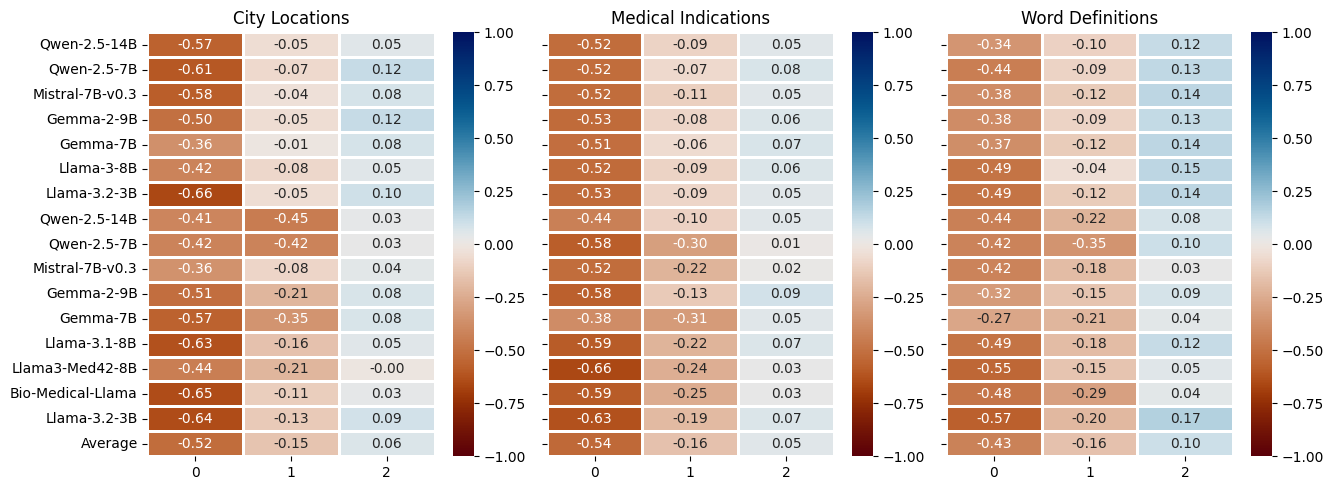

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

D_list = []

for j, datapack in enumerate(datapacks):
    D = np.zeros((len(model_names) + 1 ,3))
    for i, model in enumerate(models):
        eD_0 = ExperimentData(model_name=model, dataset_name=datapack, task=0, probe_name='sawmil', with_search=WITH_SEARCH) # true
        ed_1 = ExperimentData(model_name=model, dataset_name=datapack, task=1, probe_name='sawmil', with_search=WITH_SEARCH) # false
        ed_2 = ExperimentData(model_name=model, dataset_name=datapack, task=2, probe_name='sawmil', with_search=WITH_SEARCH) # neither
        ed = ExperimentData(model_name=model, dataset_name=datapack, task=3, probe_name='mean_diff', with_search=WITH_SEARCH) # mean_diff
        layer_id = eD_0.best_layer(keys=['conformal', 'wmcc'])
        dirs = [load_coef(eD_0, layer_id), load_coef(ed_1, layer_id), load_coef(ed_2, layer_id), load_coef(ed, layer_id)]
        D[i]= cosine_similarity(dirs)[1:,0]
    D[-1] = D[:-1].mean(axis=0)
    
    D_list.append(D)


fig, ax = plt.subplots(1, len(datapacks), figsize=(4.5 * len(datapacks),5), sharey=True)
for j, datapack in enumerate(datapacks):
    D = D_list[j]
    sns.heatmap(D,  ax=ax[j], annot=True, cmap=cm.vik_r, vmin=-1, vmax=1, 
                fmt=".2f", linewidths=0.8,
                yticklabels=[model_shortnames[m] for m in models] + ["Average"])
    ax[j].set_title(dataset_names[datapack])


plt.tight_layout()
plt.savefig(f"outputs/figures/cosine_similarity.svg", format="svg", bbox_inches="tight")
plt.show()

In [6]:
rows = []
for j, datapack in enumerate(datapacks):
    for probe in ['sawmil', 'svm']:
        for i, model in enumerate(models):
            eD_0 = ExperimentData(model_name=model, dataset_name=datapack, task=0, probe_name=probe, with_search=WITH_SEARCH) # true
            eD_1 = ExperimentData(model_name=model, dataset_name=datapack, task=1, probe_name=probe, with_search=WITH_SEARCH) # false

            r, tau, sim, rank, erank = get_scores(eD_0, eD_1)
            rows.append(
                {
                    'model': model,
                    'datapack': datapack,
                    'probe': probe,
                    'tau': tau,
                    'cosine_sim': sim,
                    'pearson_r': r,
                    'rank': rank,
                    'eff_rank': erank
                }
            )

summary = pd.DataFrame(rows)
summary

,model,datapack,probe,tau,cosine_sim,pearson_r,rank,eff_rank
0,qwen-2.5-14b,cities_loc,sawmil,-0.677306,-0.569809,-0.857940,2,1.902944
1,qwen-2.5-7b,cities_loc,sawmil,-0.713133,-0.608571,-0.865083,2,1.885926
2,mistral-7B-v0.3,cities_loc,sawmil,-0.678982,-0.376887,-0.893582,2,1.961839
3,gemma-2-9b,cities_loc,sawmil,-0.697517,-0.388030,-0.924856,2,1.959363
4,gemma-7b,cities_loc,sawmil,-0.615268,-0.362713,-0.751839,2,1.964853
...,...,...,...,...,...,...,...,...
91,_gemma-7b,defs,svm,-0.658901,-0.523062,-0.844279,2,1.920775
92,_llama-3.1-8b,defs,svm,-0.812209,-0.719833,-0.953452,2,1.822021
93,_llama-3-8b-med,defs,svm,-0.806597,-0.692596,-0.950151,2,1.840174
94,_llama-3.1-8b-bio,defs,svm,-0.757609,-0.754773,-0.920622,2,1.795608


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from cmcrameri import cm

sns.set_theme(style="whitegrid", font_scale=1.0)

datapack_order = ['cities_loc','med_indications',  'defs']
probe_order = ['svm', 'sawmil']  # svm first

order = [f"{probe}_{dp}" for probe in probe_order for dp in datapack_order]
summary['x_order'] = summary['probe'] + "_" + summary['datapack']

# --- colors ---
colors = {
    'med_indications': cm.lipariS(4),
    'cities_loc': cm.lipariS(2),
    'defs': cm.lipariS(3),
}

def return_color(name):
    for dp in colors.keys():
        if dp in name:
            return colors[dp]

palette = {
    k: return_color(k) for k in summary['x_order']
}
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

for im, metric in enumerate(['cosine_sim', 'tau']):
    ax = axes[im]
    sns.boxplot(
    data=summary,
    x='x_order', y=metric,
    hue='x_order', legend=False,    
    order=order,
    palette=palette,
    linewidth=1.5,
    fliersize=2,
    boxprops={'alpha': 0.99},
    ax=ax,
)
    ax.axhline(0, ls=':', c='gray', lw=0.8)
    ax.set_ylim(-1, 0)

    # add small visual gap between SVM and sAwMIL
    n_dp = len(datapack_order)
    ax.axvline(n_dp - 0.5, color='black', lw=1, ls='--', alpha=0.5)

    ax.set_xlabel('')
    ax.set_ylabel('Value')

plt.tight_layout()
sns.despine()
plt.savefig(save_dir / "dir_similarity.svg", format="svg", bbox_inches='tight')

plt.show()
